# Apply Migration to gprMax Simulation Data

Applies **Kirchhoff PSTM** and **Phase-Shift (Gazdag)** migration to baseline, timelapse,
and difference wavefields from gprMax ice GPR simulations.

## What this notebook does
1. **Loads** baseline and timelapse `.out` HDF5 files from gprMax and computes the difference wavefield
2. **Migrates** all three datasets with both methods (6 migrations total)
3. **Visualises** results with thesis-ready comparison figures
4. **Zooms** around the fracture interface (0.6 m) to quantify timelapse change

## Conventions
| Item | Value / Unit |
|------|--------------|
| Time axis | TWTT [ns], dt from CFL |
| Space | metres [m] |
| Velocity | m/ns (`v_ice ≈ 0.169 m/ns`) |
| Trace array | shape `(n_rx, n_t)` — receivers first |
| Image array | shape `(n_z, n_x)` — depth first |
| Baseline/Timelapse cmap | `hot_r` (Hilbert envelope) |
| Difference cmap | `RdBu_r` (raw amplitude, ±3σ) |

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import hilbert
from scipy.signal.windows import tukey
from scipy.interpolate import interp1d as _interp1d
from pathlib import Path
import time

In [5]:
def load_gprmax_out(path, component='Ez'):
    '''Load a gprMax .out HDF5 file.  Returns (bscan, dt_ns, time_ns).
    bscan shape: (n_rx, n_t).  dt_ns and time_ns in nanoseconds.
    Receivers are sorted by integer index (rx1, rx2, …) to avoid lexicographic misorder.
    '''
    with h5py.File(path, 'r') as f:
        dt_s   = float(f.attrs['dt'])
        n_iter = int(f.attrs['Iterations'])
        rxs    = sorted(f['rxs'].keys(), key=lambda s: int(s.replace('rx', '')))
        bscan  = np.stack([f['rxs'][r][component][:] for r in rxs], axis=0)
    dt_ns   = dt_s * 1e9
    time_ns = np.arange(bscan.shape[1]) * dt_ns
    return bscan, dt_ns, time_ns

In [14]:
# ── Paths  (edit these if your .out files are in a different location) ────
BASE_PATH = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\Experiment_2')
path_base = BASE_PATH / 'baseline.out'
path_time = BASE_PATH / 'timelapse.out'

# ── Survey geometry (must match inputfile_generator.ipynb) ────────────────
tx_x       = 2.0                            # source x-position [m]
rx_pos     = np.linspace(1.0, 3.0, 100)    # receiver positions [m]
v_ice      = 0.169                          # migration velocity [m/ns]
fracture_z = 0.6                            # known fracture depth [m]

# ── Image grid ────────────────────────────────────────────────────────────
x_img = np.linspace(1.0, 3.0, 200)         # [m]
z_img = np.linspace(0.0, 1.2, 120)         # [m]  — covers fracture + below

print(f'Image grid:  x {x_img[0]:.2f}–{x_img[-1]:.2f} m ({len(x_img)} pts),  '
      f'z {z_img[0]:.2f}–{z_img[-1]:.2f} m ({len(z_img)} pts)')
print(f'tx_x = {tx_x} m,  v_ice = {v_ice} m/ns,  fracture_z = {fracture_z} m')

Image grid:  x 1.00–3.00 m (200 pts),  z 0.00–1.20 m (120 pts)
tx_x = 2.0 m,  v_ice = 0.169 m/ns,  fracture_z = 0.6 m


Loaded:  shape=(100, 8000),  dt=0.00176 ns,  TW=14.063 ns
Difference range:  [-7.658e+02, 7.471e+02]


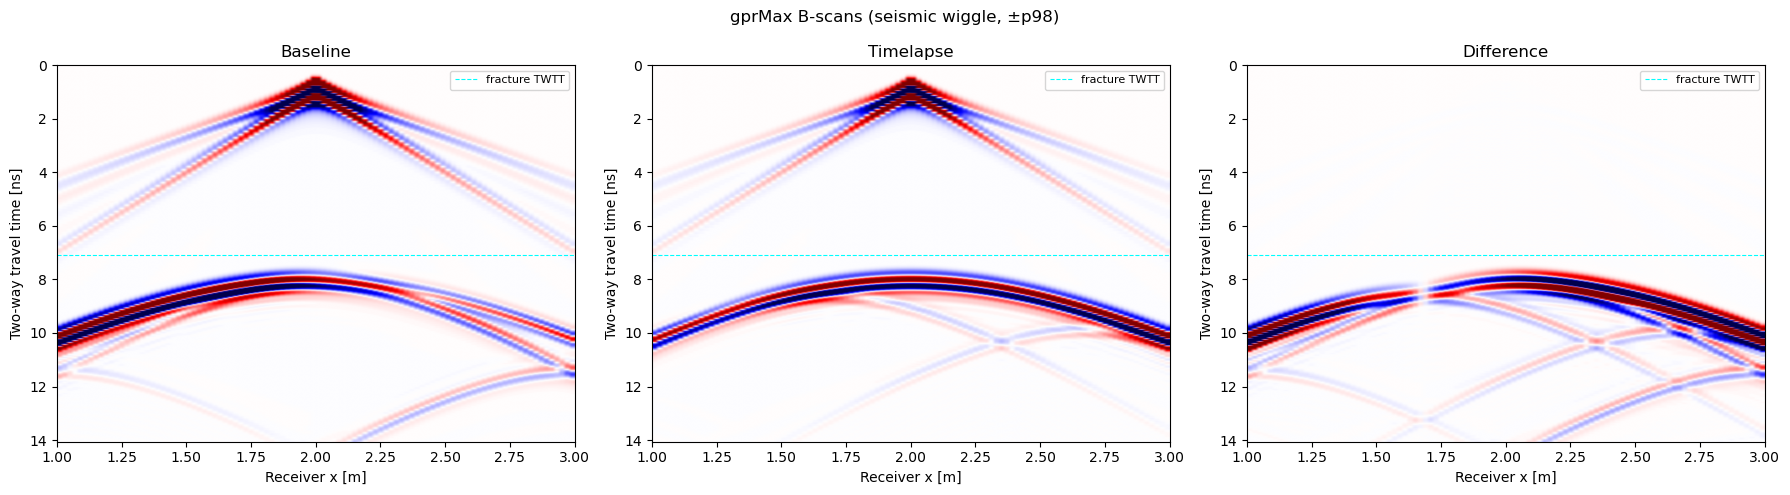

In [15]:
# ── Load files ────────────────────────────────────────────────────────────
for p in [path_base, path_time]:
    if not p.exists():
        raise FileNotFoundError(
            f'{p} not found.\n'
            'Run gprMax simulations first via run_experiment.py, '
            'then rerun this cell.')

bscan_base, dt_ns, time_ns = load_gprmax_out(path_base)
bscan_time, _,     _       = load_gprmax_out(path_time)
bscan_diff = bscan_base - bscan_time       # difference wavefield

print(f'Loaded:  shape={bscan_base.shape},  dt={dt_ns:.5f} ns,  TW={time_ns[-1]:.3f} ns')
print(f'Difference range:  [{bscan_diff.min():.3e}, {bscan_diff.max():.3e}]')

# ── 3-panel B-scan preview ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Baseline', 'Timelapse', 'Difference']
bscans = [bscan_base, bscan_time, bscan_diff]
for ax, bs, title in zip(axes, bscans, titles):
    p98 = np.percentile(np.abs(bs), 98)
    ax.imshow(bs.T, aspect='auto',
              extent=[rx_pos[0], rx_pos[-1], time_ns[-1], 0],
              cmap='seismic', vmin=-p98, vmax=p98)
    ax.axhline(2.0 * fracture_z / v_ice, color='cyan', lw=0.8, ls='--',
               label=f'fracture TWTT')
    ax.set_xlabel('Receiver x [m]')
    ax.set_ylabel('Two-way travel time [ns]')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle('gprMax B-scans (seismic wiggle, ±p98)', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# ── Kirchhoff CSG migration ───────────────────────────────────────────────
def kirchhoff_pstm(bscan, time_ns, tx_x, rx_pos, v_mns, x_img, z_img,
                   max_angle_deg=60.0, apply_obliquity=True):
    '''Kirchhoff prestack time migration for a CSG.  Returns image (n_z, n_x).

    t_sum = (r_tx + r_rx) / v_mns  (source-to-reflector + reflector-to-receiver)
    Obliquity: w = 0.5*(cos_tx + cos_rx)

    max_angle_deg controls the half-aperture.  70° captures more energy but
    leaves long "X" arms from the migration operator footprint.  60° gives a
    cleaner image at the cost of slightly reduced lateral resolution.
    '''
    dt_ns   = time_ns[1] - time_ns[0]
    n_time  = len(time_ns)
    n_rx    = len(rx_pos)
    cos_max = np.cos(np.radians(max_angle_deg))
    rx_idx  = np.arange(n_rx, dtype=np.int32)

    image = np.zeros((len(z_img), len(x_img)))

    t0_perf = time.perf_counter()
    for iz, z_out in enumerate(z_img):
        for ix, x_out in enumerate(x_img):
            r_tx  = np.sqrt((x_out - tx_x)**2 + z_out**2)          # scalar
            r_rx  = np.sqrt((x_out - rx_pos)**2 + z_out**2)         # (n_rx,)
            t_sum = (r_tx + r_rx) / v_mns                           # (n_rx,) [ns]

            t_idx  = np.round((t_sum - time_ns[0]) / dt_ns).astype(np.int32)
            cos_tx = z_out / r_tx if r_tx > 0 else 0.0
            cos_rx = z_out / r_rx
            valid  = (t_idx >= 0) & (t_idx < n_time) & (cos_rx >= cos_max)

            if not valid.any():
                continue

            amps = bscan[rx_idx[valid], t_idx[valid]]
            if apply_obliquity:
                image[iz, ix] = np.sum(0.5 * (cos_tx + cos_rx[valid]) * amps)
            else:
                image[iz, ix] = np.sum(amps)

    elapsed = time.perf_counter() - t0_perf
    print(f'Kirchhoff complete in {elapsed:.1f} s')
    return image


# ── Shot-profile Phase-Shift migration (CSG) ──────────────────────────────
def phase_shift_migration(bscan, time_ns, rx_pos, tx_x, v_mns, x_img, z_img):
    '''Shot-profile phase-shift migration for a single CSG (Gazdag / Berkhout).

    The standard Gazdag operator is designed for zero-offset data.  For a CSG,
    each trace contains an extra source-leg phase  exp(-i·ω·r_tx/v)  that varies
    with scatterer position but not with receiver position.  Applying the kz
    phase shift removes the receiver-side phase; the source-side phase is then
    removed via cross-correlation with the source Green's function G_S.

    Algorithm per depth step dz:
      1. D_accum *= exp(+i·KZ·dz)          — receiver wavefield downward continuation
      2. D_x_ω  = IFFT_kx { D_accum }     — back to x domain (nfft_x × n_t)
      3. G_S*(x,ω,z) = exp(+i·ω·r_S(x)/v) — conj. source Green's function
         where r_S(x) = sqrt((x - tx_x)² + z²)
      4. image[z,x] = Re{ Σ_ω G_S*(x,ω,z) · D_x_ω(x,ω) }  — imaging condition

    Evanescent components (kx² > (ω/v)²) are zeroed BEFORE the depth loop.
    Setting KZ=0 alone gives exp(0)=1 — no attenuation — so those bins would
    accumulate unchanged and create a coherent artifact background.

    Spatial zero-padding (2× in x) doubles the FFT period from n_rx*dx to
    2*n_rx*dx, pushing the periodic alias images outside the image range and
    eliminating the vertical stripe artifact.

    A Tukey spatial taper (α=0.10) fades only the outer 5% of traces on each
    edge — gentler than Hanning, preserves near-source and far-offset amplitudes.

    Unit check:  ω [rad/ns] / v [m/ns] → [rad/m];  r_S [m] → exponent dimensionless ✓
    Returns image (n_z, n_x) on x_img grid, normalised to peak = 1.
    '''
    n_rx, n_t = bscan.shape
    dt  = time_ns[1] - time_ns[0]          # [ns]
    dx  = rx_pos[1]  - rx_pos[0]           # [m]
    n_z = len(z_img)

    # 2× padding doubles the FFT period to 2*n_rx*dx so periodic alias images
    # land outside the image domain.
    nfft_x = 2 * n_rx

    omega = 2.0 * np.pi * np.fft.fftfreq(n_t,    d=dt)     # [rad/ns]   (n_t,)
    kx    = 2.0 * np.pi * np.fft.fftfreq(nfft_x, d=dx)     # [rad/m]    (nfft_x,)
    KX, OM = np.meshgrid(kx, omega, indexing='ij')           # (nfft_x, n_t)

    arg = (OM / v_mns) ** 2 - KX ** 2
    KZ  = np.where(arg > 0.0, np.sqrt(arg), 0.0)            # [rad/m]

    x_ifft   = np.arange(nfft_x) * dx                       # (nfft_x,) [m]
    d_x_ifft = x_ifft - tx_x

    # Tukey α=0.10: only 5% cosine fade per edge (gentler than Hanning for real data)
    taper = tukey(n_rx, alpha=0.10)                          # (n_rx,)

    D_accum = np.fft.fft2(bscan * taper[:, np.newaxis], s=(nfft_x, n_t))

    # Mute evanescent components before depth loop — setting KZ=0 alone is
    # insufficient because exp(1j*0*dz)=1 still multiplies D_accum by 1.
    D_accum[arg <= 0.0] = 0.0

    image   = np.zeros((n_z, nfft_x))
    z_prev  = 0.0
    t0_perf = time.perf_counter()

    for iz, z_out in enumerate(z_img):
        dz = z_out - z_prev
        if dz > 0.0:
            D_accum *= np.exp(1j * KZ * dz)

        D_x_ω = np.fft.ifft(D_accum, axis=0)            # (nfft_x, n_t) complex

        r_S      = np.sqrt(d_x_ifft**2 + z_out**2)      # (nfft_x,)
        G_S_conj = np.exp(1j * np.outer(r_S / v_mns, omega))  # (nfft_x, n_t)

        image[iz] = np.real(np.sum(G_S_conj * D_x_ω, axis=1))
        z_prev = z_out

    elapsed = time.perf_counter() - t0_perf
    print(f'Phase-shift complete in {elapsed:.2f} s')

    n_x       = len(x_img)
    image_out = np.zeros((n_z, n_x))
    for iz in range(n_z):
        image_out[iz] = _interp1d(x_ifft, image[iz], kind='linear',
                                   bounds_error=False, fill_value=0.0)(x_img)

    peak = np.max(np.abs(image_out))
    if peak > 0.0:
        image_out /= peak
    return image_out


# ── Focusing quality (optional — useful if ground-truth depth is known) ────
def focusing_quality(migrated, x_img, z_img, targets,
                     search_radius_m=0.15, peak_box_pixels=3):
    '''Per-target: position error (m) + focusing ratio FR = E_window / E_total.'''
    env    = np.abs(hilbert(migrated, axis=0))
    E_tot  = np.sum(env**2) + 1e-30
    dx     = x_img[1] - x_img[0]
    dz     = z_img[1] - z_img[0]
    results = []

    for tgt in targets:
        x_t, z_t = tgt['x'], tgt['z']
        ix_c = np.argmin(np.abs(x_img - x_t))
        iz_c = np.argmin(np.abs(z_img - z_t))
        r_px_x = int(np.ceil(search_radius_m / dx))
        r_px_z = int(np.ceil(search_radius_m / dz))
        ix_lo = max(0, ix_c - r_px_x);  ix_hi = min(len(x_img)-1, ix_c + r_px_x)
        iz_lo = max(0, iz_c - r_px_z);  iz_hi = min(len(z_img)-1, iz_c + r_px_z)

        window  = env[iz_lo:iz_hi+1, ix_lo:ix_hi+1]
        pk_flat = np.argmax(window)
        pk_iz, pk_ix = np.unravel_index(pk_flat, window.shape)
        pk_iz += iz_lo;  pk_ix += ix_lo

        pos_err = np.sqrt((x_img[pk_ix]-x_t)**2 + (z_img[pk_iz]-z_t)**2)
        bx_lo_z = max(0, pk_iz-peak_box_pixels);  bx_hi_z = min(len(z_img)-1, pk_iz+peak_box_pixels)
        bx_lo_x = max(0, pk_ix-peak_box_pixels);  bx_hi_x = min(len(x_img)-1, pk_ix+peak_box_pixels)
        FR = np.sum(env[bx_lo_z:bx_hi_z+1, bx_lo_x:bx_hi_x+1]**2) / E_tot
        results.append({'label': tgt['label'], 'x_true': x_t, 'z_true': z_t,
                        'x_peak': x_img[pk_ix], 'z_peak': z_img[pk_iz],
                        'pos_error_m': pos_err, 'focusing_ratio': FR})

    print(f'{"Label":<6} {"True (x,z)":<16} {"Peak (x,z)":<16} {"Err [cm]":>9} {"FR":>8}')
    print('-' * 60)
    for r in results:
        print(f"{r['label']:<6} ({r['x_true']:.2f},{r['z_true']:.2f})        "
              f"({r['x_peak']:.3f},{r['z_peak']:.3f})    "
              f"{r['pos_error_m']*100:>7.2f}  {r['focusing_ratio']:>8.5f}")
    return results


print('Migration functions defined (kirchhoff_pstm, phase_shift_migration, focusing_quality)')

Migration functions defined (kirchhoff_pstm, phase_shift_migration, focusing_quality)


In [17]:
datasets = {
    'Baseline':   bscan_base,
    'Timelapse':  bscan_time,
    'Difference': bscan_diff,
}

results = {}    # keys: (dataset_name, method_name)
timings = {}

for ds_name, bs in datasets.items():
    print(f'\n── {ds_name} ──')
    t0 = time.perf_counter()
    img_kh = kirchhoff_pstm(bs, time_ns, tx_x, rx_pos, v_ice, x_img, z_img)
    timings[(ds_name, 'Kirchhoff')] = time.perf_counter() - t0
    results[(ds_name, 'Kirchhoff')] = img_kh

    t0 = time.perf_counter()
    img_ps = phase_shift_migration(bs, time_ns, rx_pos, tx_x, v_ice, x_img, z_img)
    timings[(ds_name, 'Phase-Shift')] = time.perf_counter() - t0
    results[(ds_name, 'Phase-Shift')] = img_ps

    print(f'  Kirchhoff shape   = {img_kh.shape}')
    print(f'  Phase-Shift shape = {img_ps.shape}')

# ── Timing table ──────────────────────────────────────────────────────────
print('\n' + '─'*55)
print(f'{"Dataset":12s}  {"Kirchhoff [s]":>14s}  {"Phase-Shift [s]":>16s}')
print('─'*55)
for ds in datasets:
    kh = timings[(ds, 'Kirchhoff')]
    ps = timings[(ds, 'Phase-Shift')]
    print(f'{ds:12s}  {kh:>14.2f}  {ps:>16.2f}')
print('─'*55)


── Baseline ──


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25120\3445628926.py:30: RuntimeWarning: invalid value encountered in divide
  cos_rx = z_out / r_rx


Kirchhoff complete in 0.6 s


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25120\3445628926.py:92: RuntimeWarning: invalid value encountered in sqrt
  KZ  = np.where(arg > 0.0, np.sqrt(arg), 0.0)            # [rad/m]


Phase-shift complete in 14.10 s
  Kirchhoff shape   = (120, 200)
  Phase-Shift shape = (120, 200)

── Timelapse ──
Kirchhoff complete in 0.6 s
Phase-shift complete in 14.02 s
  Kirchhoff shape   = (120, 200)
  Phase-Shift shape = (120, 200)

── Difference ──
Kirchhoff complete in 0.6 s
Phase-shift complete in 14.06 s
  Kirchhoff shape   = (120, 200)
  Phase-Shift shape = (120, 200)

───────────────────────────────────────────────────────
Dataset        Kirchhoff [s]   Phase-Shift [s]
───────────────────────────────────────────────────────
Baseline                0.62             14.16
Timelapse               0.61             14.08
Difference              0.61             14.12
───────────────────────────────────────────────────────


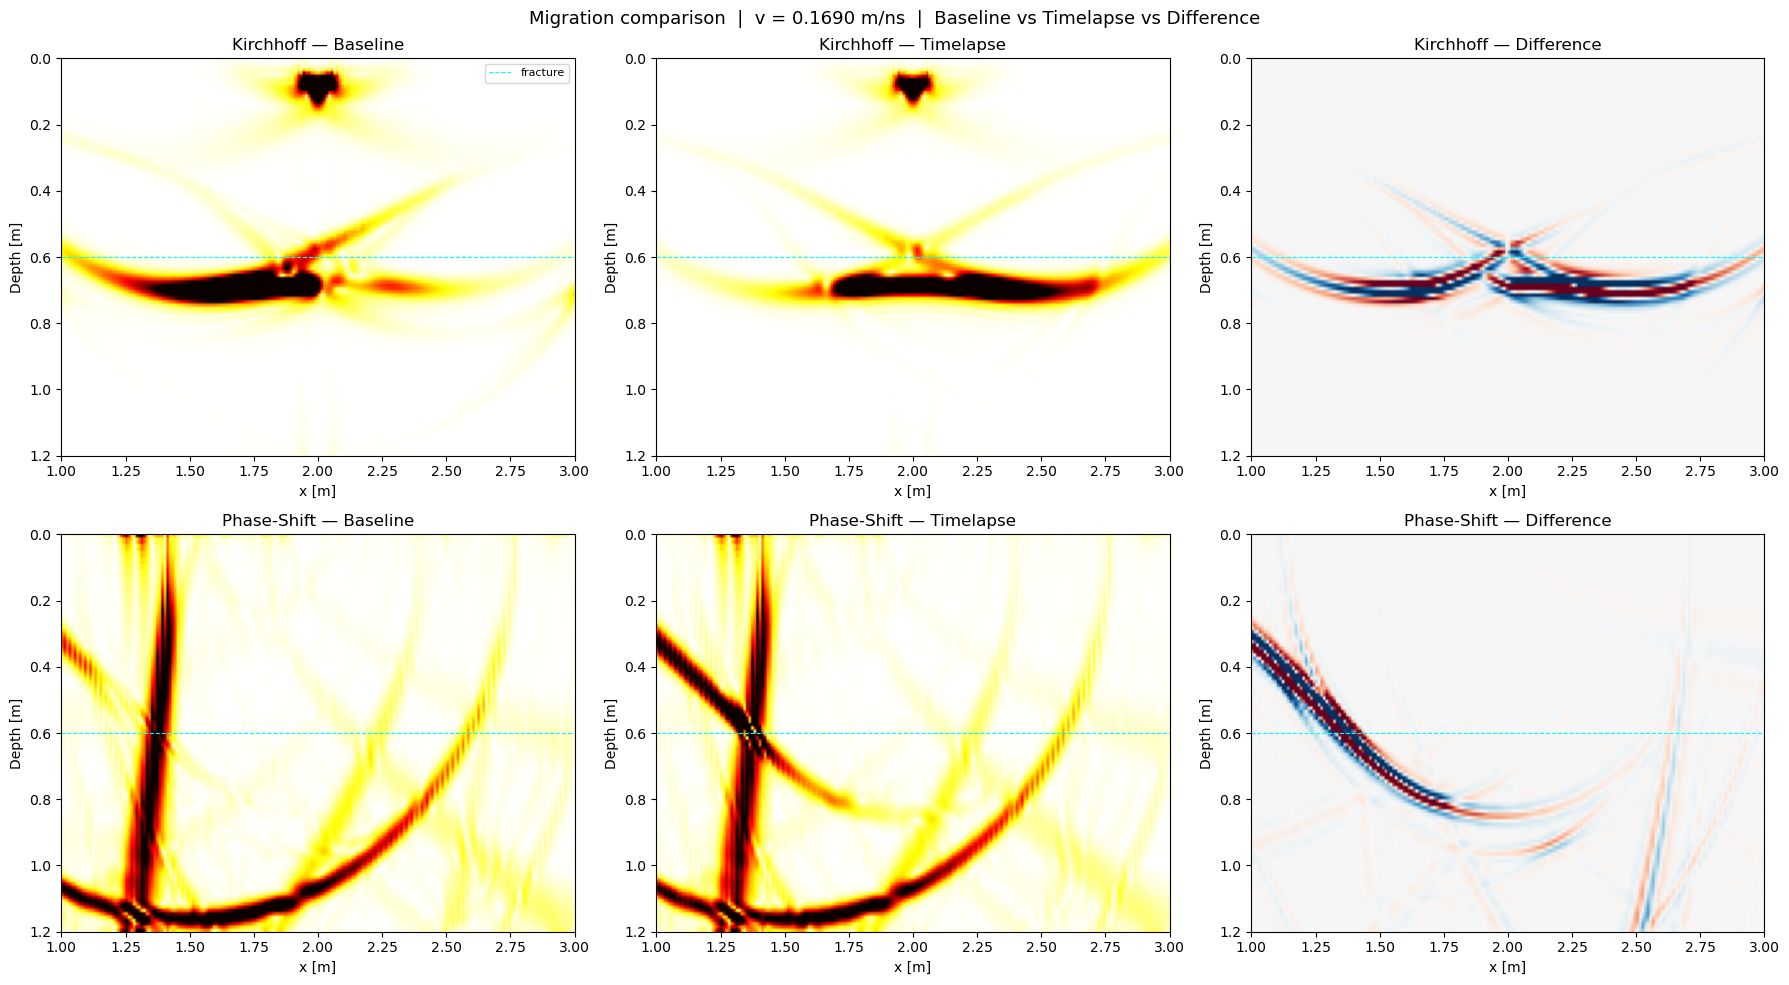

In [18]:
method_names = ['Kirchhoff', 'Phase-Shift']
ds_names     = ['Baseline', 'Timelapse', 'Difference']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, mth in enumerate(method_names):
    for col, ds in enumerate(ds_names):
        ax  = axes[row, col]
        img = results[(ds, mth)]

        if ds == 'Difference':
            # Raw amplitude — diverging colormap, ±3σ
            vmax = 3.0 * np.std(img)
            ax.imshow(img, aspect='auto',
                      extent=[x_img[0], x_img[-1], z_img[-1], z_img[0]],
                      cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='upper')
        else:
            # Hilbert envelope — hot_r
            norm = img / (np.max(np.abs(img)) + 1e-30)
            env  = np.abs(hilbert(norm, axis=0))
            vmax = np.percentile(env, 98)
            ax.imshow(env, aspect='auto',
                      extent=[x_img[0], x_img[-1], z_img[-1], z_img[0]],
                      cmap='hot_r', vmin=0, vmax=vmax, origin='upper')

        ax.axhline(fracture_z, color='cyan', lw=0.8, ls='--', label='fracture')
        ax.set_xlabel('x [m]')
        ax.set_ylabel('Depth [m]')
        ax.set_title(f'{mth} — {ds}')

axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle(f'Migration comparison  |  v = {v_ice:.4f} m/ns  |  '
             f'Baseline vs Timelapse vs Difference', fontsize=13)
plt.tight_layout()
plt.show()

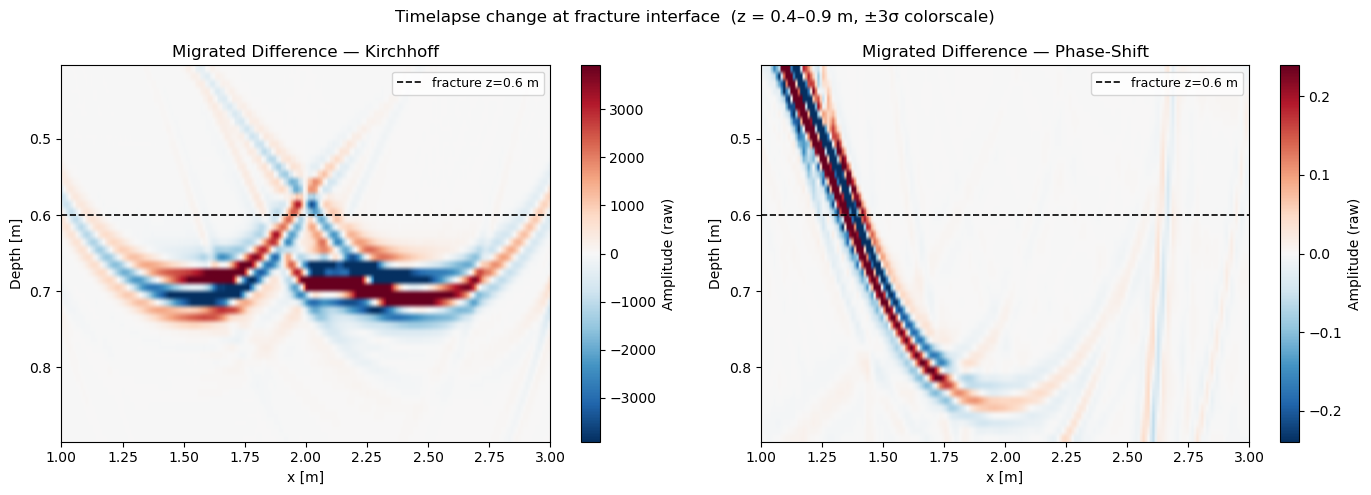

In [19]:
# ── Zoomed difference comparison around fracture interface (thesis figure) ─
z_lo, z_hi = 0.4, 0.9
z_mask = (z_img >= z_lo) & (z_img <= z_hi)
z_zoom = z_img[z_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mth in zip(axes, method_names):
    img   = results[('Difference', mth)]
    img_z = img[z_mask, :]
    vmax  = 3.0 * np.std(img_z)
    im = ax.imshow(img_z, aspect='auto',
                   extent=[x_img[0], x_img[-1], z_zoom[-1], z_zoom[0]],
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='upper')
    ax.axhline(fracture_z, color='k', lw=1.2, ls='--', label=f'fracture z={fracture_z} m')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('Depth [m]')
    ax.set_title(f'Migrated Difference — {mth}')
    ax.legend(fontsize=9, loc='upper right')
    plt.colorbar(im, ax=ax, label='Amplitude (raw)')

fig.suptitle('Timelapse change at fracture interface  '
             f'(z = {z_lo}–{z_hi} m, ±3σ colorscale)', fontsize=12)
plt.tight_layout()
plt.show()

## Interpretation

### Reading the panels
- **Baseline / Timelapse** (`hot_r`, Hilbert envelope): bright dots indicate focused reflectors. The fracture interface at 0.6 m should appear as a horizontal band of energy; block geometry creates lateral amplitude variation.
- **Difference** (`RdBu_r`, raw amplitude, ±3σ): blue = signal is stronger in baseline; red = stronger in timelapse. A **polarity-reversal pattern** straddling `fracture_z` (blue above, red below or vice versa) is the hallmark of a block-shift-driven timelapse change.

### Kirchhoff vs Phase-Shift on real data
| Criterion | Kirchhoff | Phase-Shift |
|-----------|-----------|-------------|
| Speed | Fast (pure Python loops, ~1 s/migration) | Slower (FFT depth loop, ~10–20 s) |
| Coda suppression | Finite aperture → residual X-arms | Full angular spectrum → cleaner collapse |
| Alias sensitivity | Not affected | Requires spatial zero-padding (2×) |
| Diffraction handling | Single-arrival approximation | Exact wave-equation propagator |

### Tukey taper (α = 0.10)
Only the outer 5% of traces on each edge are cosine-tapered to zero. This is gentler than a Hanning window and better suited to real data where amplitude naturally decays with offset — a full Hanning taper would suppress the far-offset traces that carry critical wide-angle information for the fracture reflector.